# Preprocessing and Baseline Model

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay

plt.style.use("default")

In [2]:
# Loading raw data
data = pd.read_csv("../data/raw/telco_churn.csv")
data.shape

(7043, 21)

In [3]:
##### Minimal cleaning without leakage #####

# Converting TotalCharges to numeric data type
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors = "coerce")

# Dropping rows with invalid TotalCharges
data = data.dropna(subset = ["TotalCharges"])

data.shape

(7032, 21)

- "TotalCharges" was coerced into a numeric data type, and a small amount of invalid rows were removed. Nothing that is dependent on modelling has been applied yet at this stage.

In [4]:
# Defining the features and the target
X = data.drop(columns = ["Churn", "customerID"])
y = data["Churn"].map({"No": 0, "Yes": 1})

# Sanity check
X.shape, y.shape

((7032, 19), (7032,))

In [5]:
# Identifying the feature types
features_numeric = X.select_dtypes(include = ["int64", "float64"]).columns.tolist()
features_categorical = X.select_dtypes(include = ["object"]).columns.tolist()

# Displaying the lists
features_numeric, features_categorical

(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

In [6]:
# Splitting data into train and test/val sets
X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size = 0.3, stratify = y, 
                                                            random_state = 42)

X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size = 0.5,
                                                stratify = y_val_test, random_state = 42)

# Sanity check
X_train.shape, X_val.shape, X_test.shape

((4922, 19), (1055, 19), (1055, 19))

- Data was split into the following sets: 70% training, 15% validation, and 15% test. Stratified sampling was also used because of class imbalance.

In [7]:
##### Preprocessing pipeline #####

# Numeric feature pipeline:
# - All numeric preprocessing is grouped into a reusable unit
# - Median imputation restricts distortion and is robust to outliers
# - Scaling is needed as the model is gradient based
transformer_numeric = Pipeline(steps = [("imputer", SimpleImputer(strategy = "median")),
                                        ("scaler", StandardScaler())])

# Categorical feature pipeline:
# - Missing categories are handled with the most common value for mode structure preservation
# - One-hot encoding turns categories into numeric form for models
# - handle_unknown = "ignore", is used to avoid runtime errors on unseen categories
transformer_categorical = Pipeline(steps = [("imputer", SimpleImputer(strategy = "most_frequent")),
                                            ("onehot", OneHotEncoder(handle_unknown = "ignore"))])

# ColumnTransformer to avoid data leakage and to maintain reproducibility
preprocessor = ColumnTransformer(transformers = [("num", transformer_numeric, features_numeric),
                                                 ("cat", transformer_categorical, features_categorical)])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

- Pipelines define how each feature is going to be processed, and ColumnTransformer defines where each pipeline is going to be applied.
- Imputation and scaling is only used on training data

In [8]:
# Defining the logistic regression model
# - class_weight = "balanced" adresses the class imbalance
log_regression_model = LogisticRegression(max_iter = 2000, class_weight = "balanced",
                                          random_state = 42)

In [9]:
# Combine all pipelines into one
clf = Pipeline(steps = [("preprocessor", preprocessor), ("model", log_regression_model)])

clf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [10]:
# Fitting the model, but for the training set only
clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [11]:
##### Model validation #####

# ROC-AUC (the main metric)
y_val_proba = clf.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_val_proba)

roc_auc

0.8531292817273121

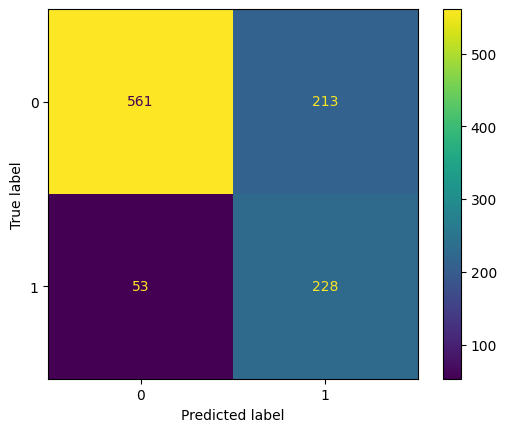

In [12]:
##### Model validation part 2 ####

# Confusion matrix
y_val_pred = clf.predict(X_val)

ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)
plt.show()

- The logistic regression model produces more false positives with 213, than false negatives that is 53. This mean that it frequently selects Class 1 when the true label is Class 0. 
- The model is aggresive at threshold 0.5, which is arbitrary
- Tuning the threshold is advisible because it allows trade between the false positives and false negatives. 

In [13]:
##### Extracting feature names #####

# Getting the feature names after preprocessing
feature_names_numeric = features_numeric
feature_names_categorical = clf.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(features_categorical)
            
feature_names = np.concatenate([feature_names_numeric, feature_names_categorical])
len(feature_names)

45

In [22]:
# Extracting and interpreting coefficients
coefficients = clf.named_steps["model"].coef_[0]

coef_data = pd.DataFrame({"feature": feature_names, "coefficient": coefficients}).sort_values(
    by = "coefficient", ascending = False)

coef_data.head(10), coef_data.tail(10)

(                           feature  coefficient
 3                     TotalCharges     0.680998
 36         Contract_Month-to-month     0.649806
 16     InternetService_Fiber optic     0.597696
 35             StreamingMovies_Yes     0.215006
 43  PaymentMethod_Electronic check     0.213397
 32                 StreamingTV_Yes     0.213392
 18               OnlineSecurity_No     0.210668
 27                  TechSupport_No     0.205514
 14               MultipleLines_Yes     0.114270
 21                 OnlineBackup_No     0.087185,
                                  feature  coefficient
 22      OnlineBackup_No internet service    -0.237163
 17                    InternetService_No    -0.237163
 34   StreamingMovies_No internet service    -0.237163
 31       StreamingTV_No internet service    -0.237163
 25  DeviceProtection_No internet service    -0.237163
 12                      MultipleLines_No    -0.242743
 2                         MonthlyCharges    -0.504289
 15                 

It's important to note that:
- Positive coefficients increases churn probability
- Negative coefficients decrease churn probability 

In [27]:
# Converting to odds ratio
coef_data["odds_ratio"] = np.exp(coef_data["coefficient"])
coef_data.sort_values("odds_ratio", ascending = False).head(10)[["feature", "coefficient", "odds_ratio"]]


,feature,coefficient,odds_ratio
3,TotalCharges,0.680998,1.975849
36,Contract_Month-to-month,0.649806,1.915170
16,InternetService_Fiber optic,0.597696,1.817925
35,StreamingMovies_Yes,0.215006,1.239869
43,PaymentMethod_Electronic check,0.213397,1.237876
32,StreamingTV_Yes,0.213392,1.237869
18,OnlineSecurity_No,0.210668,1.234502
27,TechSupport_No,0.205514,1.228156
14,MultipleLines_Yes,0.114270,1.121054
21,OnlineBackup_No,0.087185,1.091098


- H1: It is supported. Month-to-month OR = 1.91
- H2: It is supported. Tenure OR = 0.27 (protective)
- H3: It is partially supported. Charges effect context dependent